In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('sex_bmi_smokers.csv')
df.head()

,sex,bmi,smoker
0,female,27.900,yes
1,male,33.770,no
2,male,33.000,no
3,male,22.705,no
4,male,28.880,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sex     1338 non-null   object 
 1   bmi     1338 non-null   float64
 2   smoker  1338 non-null   object 
dtypes: float64(1), object(2)
memory usage: 31.5+ KB


In [ ]:
# Наиболее представленная категория
df.groupby(['sex', 'smoker']).count().idxmax().iloc[0]

('female', 'no')

In [16]:
# Общие статистики
print(f"Среднее ИМТ: {df['bmi'].mean():.2f}")
print(f"Дисперсия ИМТ: {df['bmi'].var():.2f}")
print(f"Медиана ИМТ: {df['bmi'].median():.2f}")
print(f"Квантиль 0.7 ИМТ: {df['bmi'].quantile(0.7):.2f}")

Среднее ИМТ: 30.66
Дисперсия ИМТ: 37.19
Медиана ИМТ: 30.40
Квантиль 0.7 ИМТ: 33.66


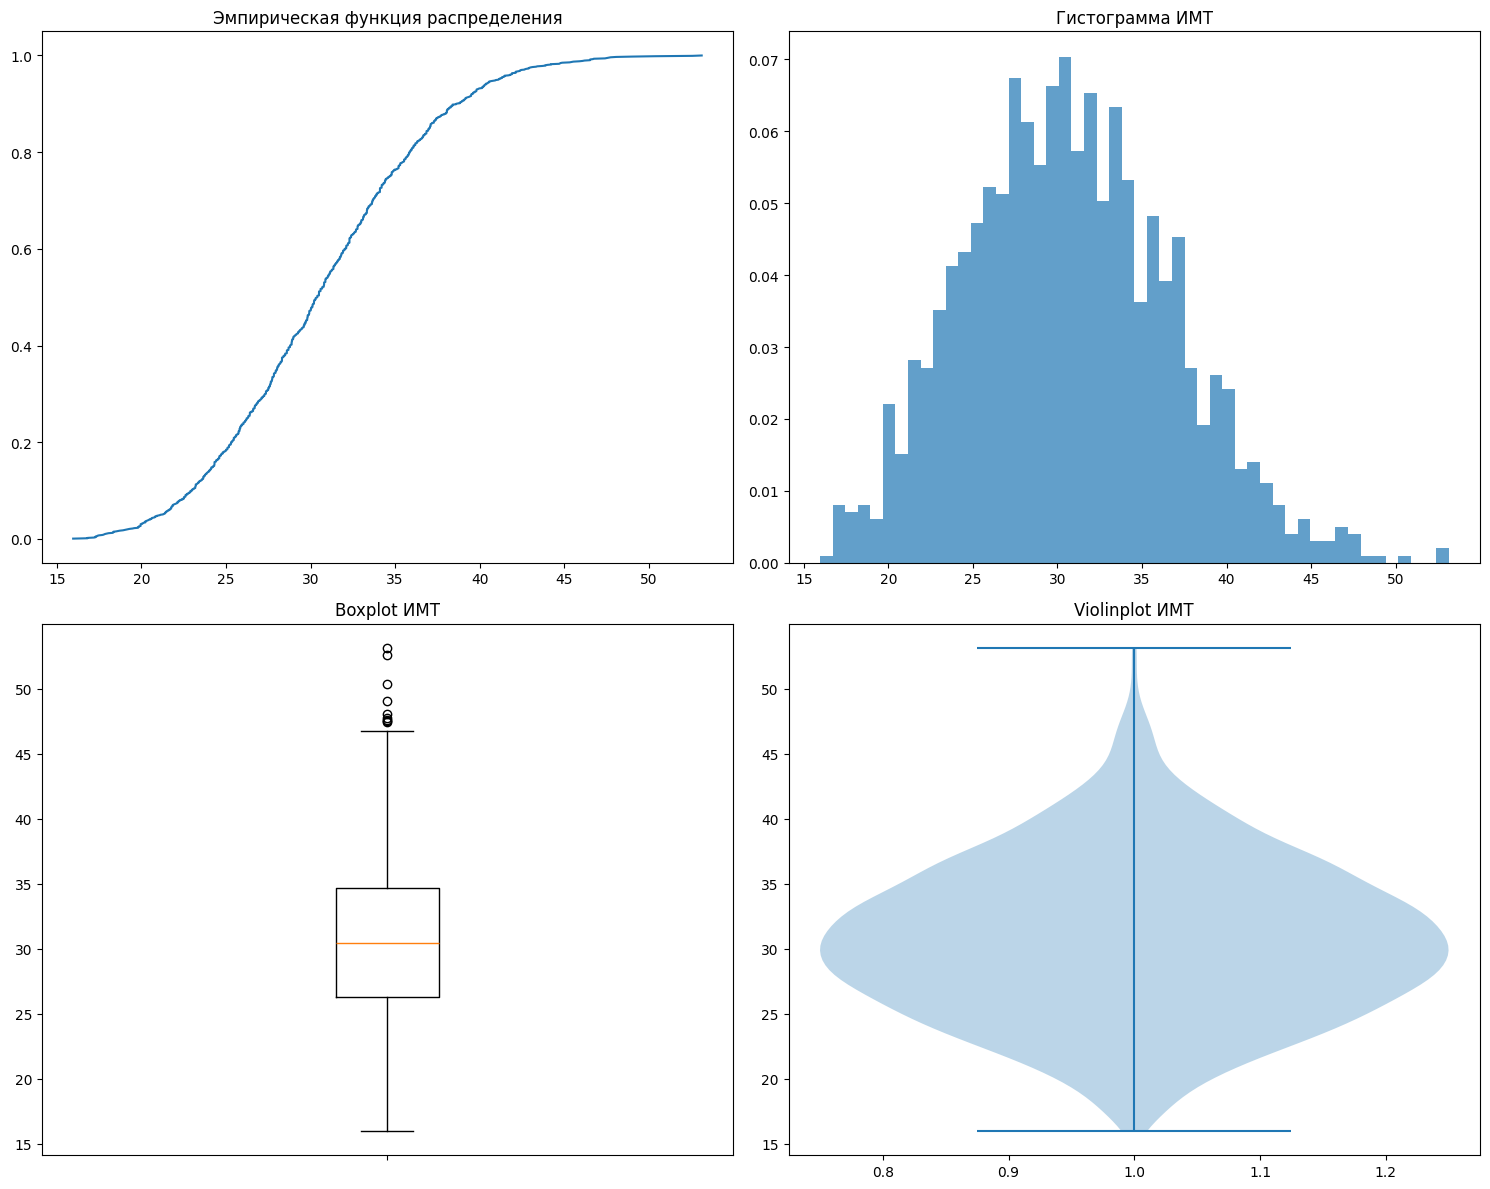

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0,0].plot(np.sort(df['bmi']), np.arange(1, len(df)+1) / len(df))
axes[0,0].set_title('Эмпирическая функция распределения')

axes[0,1].hist(df['bmi'], bins=50, density=True, alpha=0.7)
axes[0,1].set_title('Гистограмма ИМТ')

axes[1,0].boxplot(df['bmi'])
axes[1,0].set_xticklabels([])
axes[1,0].set_title('Boxplot ИМТ')

axes[1,1].violinplot(df['bmi'])
axes[1,1].set_title('Violinplot ИМТ')

plt.tight_layout()
plt.show()

In [ ]:
df.groupby(['sex', 'smoker'])['bmi'].apply(list).tolist()

517

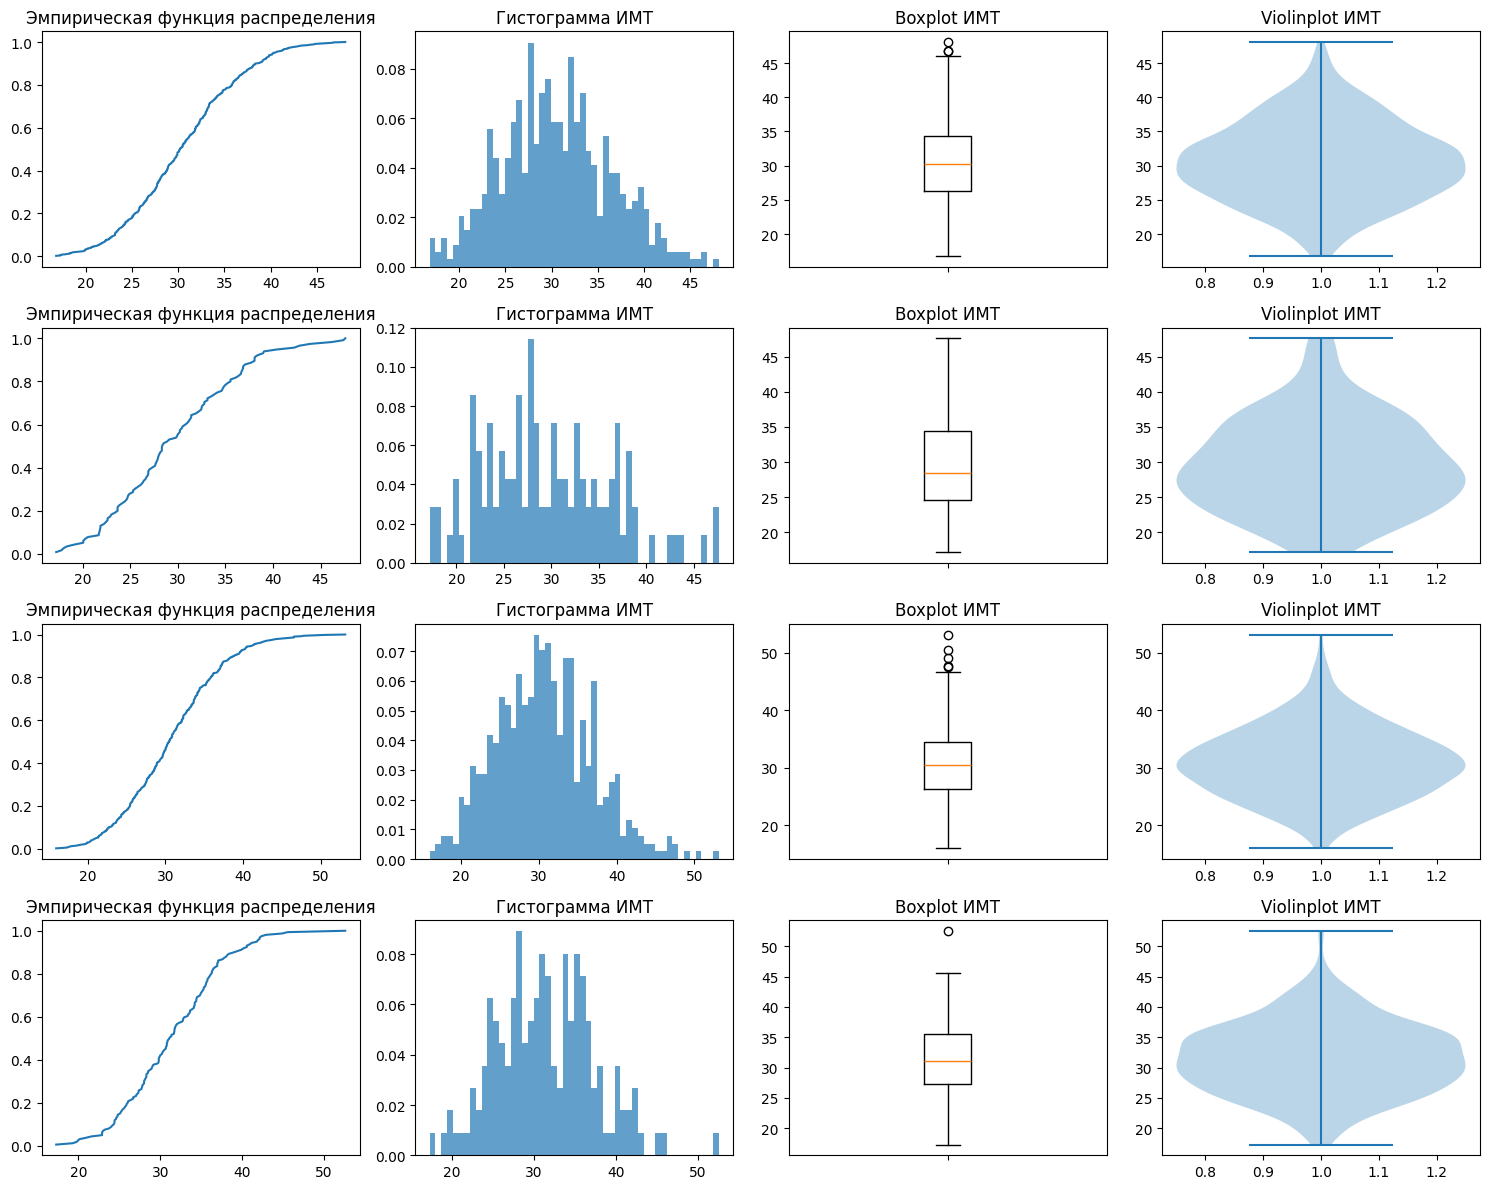

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))

for i, bmi in enumerate(df.groupby(['sex', 'smoker'])['bmi'].apply(list).tolist()):
    axes[i, 0].plot(np.sort(bmi), np.arange(1, len(bmi)+1) / len(bmi))
    axes[i, 0].set_title('Эмпирическая функция распределения')

    axes[i, 1].hist(bmi, bins=50, density=True, alpha=0.7)
    axes[i, 1].set_title('Гистограмма ИМТ')

    axes[i, 2].boxplot(bmi)
    axes[i, 2].set_xticklabels([])
    axes[i, 2].set_title('Boxplot ИМТ')

    axes[i, 3].violinplot(bmi)
    axes[i, 3].set_title('Violinplot ИМТ')
plt.tight_layout()
plt.show()